# Intro

In [1]:
import pandas as pd

%cd /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/

/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis


In [77]:
TEST_RESULTS_PATH = 'thesis-figures/extended_cbm/results/2_test_metrics_aab_maskreg-intro.parquet'
VAL_RESULTS_PATH_RAW = 'thesis-figures/extended_cbm/results/1_extended_cbm_results.parquet'

In [78]:
def create_summary_table(df: pd.DataFrame, filter_tag:list[str], reference_measure:str):
    """Erstellt eine Tabelle mit den Bestwerten pro Run."""
    print("\nErstelle Summary Tabelle (Max-Werte)...")

    # filter df for each column where df[column] is true
    for tag in filter_tag:
        col = f"tag_{tag}"
        if col not in df.columns:
            raise ValueError(f"Tag-Spalte {col} existiert nicht im DataFrame.")
        df = df[df[col] == True]

    if df.empty:
        print("DataFrame nach Tag-Filter leer.")
        return df

    # Sicherstellen, dass innerhalb jedes Runs nach step sortiert ist
    df = df.sort_values(["run_id", "_step"]).copy()

    # Epoch als laufende Evaluation pro run_id (startet bei 0)
    df["epoch"] = df.groupby("run_id").cumcount()

    # Bestes F1-Concept pro Run auswählen
    best_per_run = (
        df.loc[df.groupby("run_id")[reference_measure].idxmax()]
        .reset_index(drop=True)
    )
    
    # Speichern
    best_per_run.to_parquet("thesis-figures/extended_cbm/results/2_extended_cbm_results_best.parquet")
    print("Tabelle gespeichert unter: 2_extended_cbm_results_best.parquet")
    return best_per_run

In [79]:
# test_results = pd.read_parquet(TEST_RESULTS_PATH)
val_results_raw = pd.read_parquet(VAL_RESULTS_PATH_RAW)

val_results_mask_reg = create_summary_table(val_results_raw, filter_tag=["aab-con-maskreg-intro"], reference_measure=r'$F_1$ Concept')
val_results_baseline = create_summary_table(val_results_raw, filter_tag=["aab-con"], reference_measure=r'$F_1$ Concept')
val_results_baseline = val_results_baseline[(val_results_baseline['Dataset']=='CUB_112') & (val_results_baseline['Segmentation Module']=='Upscaled MultiLayer')]


Erstelle Summary Tabelle (Max-Werte)...
Tabelle gespeichert unter: 2_extended_cbm_results_best.parquet

Erstelle Summary Tabelle (Max-Werte)...
Tabelle gespeichert unter: 2_extended_cbm_results_best.parquet


In [80]:
val_results_mask_reg['run_id'].nunique(), val_results_baseline['run_id'].nunique()

(3, 3)

In [81]:
val_results_mask_reg.head()

,_step,Recall-Concept,Precision-Concept,Total Loss,IoU-Mean,Foreground-Dice,$F_1$ Concept,Dice,Accuracy-Concept,Runtime (s),...,unified_model,Dataset,tag_Final,tag_aab-seg-benchmark,Loss Concepts,tag_aab-con,tag_aab-con-maskreg-intro,tag_aab-soft-bce,tag_aab-aff,epoch
0,1798,0.493766,0.595827,0.394846,0.735160,0.156812,0.528115,0.744520,0.826355,11543.041050,...,None,CUB_112,True,None,0.394589,None,True,None,None,23
1,1798,0.490005,0.591157,0.398096,0.563704,0.222280,0.524466,0.578550,0.824432,14218.873145,...,None,CUB_112,True,None,0.397139,None,True,None,None,23
2,1498,0.496316,0.591103,0.389537,0.710313,0.213220,0.528256,0.723023,0.825498,11787.990558,...,None,CUB_112,True,None,0.389190,None,True,None,None,19


In [184]:
# Spalten auswählen
# cols = ['run_id', 'Concept Module', 'epoch', 'Dataset']
reg = val_results_mask_reg.copy()
baseline = val_results_baseline.copy()

# Neue Spalte für Mask Regularization
reg['uses_mask_reg'] = True
baseline['uses_mask_reg'] = False

# Zusammenführen
combined = pd.concat([reg, baseline], ignore_index=True)
combined['Concept Module'] = combined['Concept Module'].replace({'MaxPool': 'Maximum\nPooling', 'Top-K AvgPool': r"Top-$\rho$" +"\nAverage Pooling", 'SoftmaxWeightedPooling':'Spatial Softmax\nAttention Pooling'})
combined

,_step,Recall-Concept,Precision-Concept,Total Loss,IoU-Mean,Foreground-Dice,$F_1$ Concept,Dice,Accuracy-Concept,Runtime (s),...,Dataset,tag_Final,tag_aab-seg-benchmark,Loss Concepts,tag_aab-con,tag_aab-con-maskreg-intro,tag_aab-soft-bce,tag_aab-aff,epoch,uses_mask_reg
0,1798,0.493766,0.595827,0.394846,0.735160,0.156812,0.528115,0.744520,0.826355,11543.041050,...,CUB_112,True,None,0.394589,None,True,None,None,23,True
1,1798,0.490005,0.591157,0.398096,0.563704,0.222280,0.524466,0.578550,0.824432,14218.873145,...,CUB_112,True,None,0.397139,None,True,None,None,23,True
2,1498,0.496316,0.591103,0.389537,0.710313,0.213220,0.528256,0.723023,0.825498,11787.990558,...,CUB_112,True,None,0.389190,None,True,None,None,19,True
3,1798,0.486024,0.591199,0.395964,0.566407,0.211409,0.522210,0.580682,0.824924,21113.879250,...,CUB_112,True,None,0.395964,True,None,None,None,23,False
4,1498,0.499709,0.588192,0.388811,0.711210,0.214343,0.530185,0.723925,0.825386,17608.673553,...,CUB_112,True,None,0.388811,True,None,None,None,19,False
5,1798,0.495179,0.595187,0.394514,0.735324,0.156485,0.529490,0.744642,0.826325,21142.113909,...,CUB_112,True,None,0.394514,True,None,None,None,23,False


In [189]:
combined[['Concept Module', 'uses_mask_reg', 'Recall-Concept', 'Precision-Concept', 'IoU-Mean', 'Foreground-Dice', '$F_1$ Concept', 'Dice', 'Accuracy-Concept']].sort_values(by=['Concept Module', 'uses_mask_reg'])

,Concept Module,uses_mask_reg,Recall-Concept,Precision-Concept,IoU-Mean,Foreground-Dice,$F_1$ Concept,Dice,Accuracy-Concept
5,Maximum\nPooling,False,0.495179,0.595187,0.735324,0.156485,0.529490,0.744642,0.826325
0,Maximum\nPooling,True,0.493766,0.595827,0.735160,0.156812,0.528115,0.744520,0.826355
3,Spatial Softmax\nAttention Pooling,False,0.486024,0.591199,0.566407,0.211409,0.522210,0.580682,0.824924
1,Spatial Softmax\nAttention Pooling,True,0.490005,0.591157,0.563704,0.222280,0.524466,0.578550,0.824432
4,Top-$\rho$\nAverage Pooling,False,0.499709,0.588192,0.711210,0.214343,0.530185,0.723925,0.825386
2,Top-$\rho$\nAverage Pooling,True,0.496316,0.591103,0.710313,0.213220,0.528256,0.723023,0.825498


# Test results

In [2]:
import numpy as np
import pandas as pd


In [3]:
TEST_RESULTS_PATH_MASKREG = 'thesis-figures/extended_cbm/results/2_test_metrics_aab_maskreg-intro.parquet'

test_results = pd.read_parquet(TEST_RESULTS_PATH_MASKREG)
print(test_results[["Recall Concepts", "Precision Concepts", "Mean IoU", "Foreground Dice", "Concept Activations $F_1$-Score", "Mean Dice", "Concept Accuracy", "run_id"]].to_latex())

\begin{tabular}{lrrrrrrrl}
\toprule
 & Recall Concepts & Precision Concepts & Mean IoU & Foreground Dice & Concept Activations $F_1$-Score & Mean Dice & Concept Accuracy & run_id \\
\midrule
0 & 0.501046 & 0.596500 & 0.735050 & 0.158443 & 0.532584 & 0.744500 & 0.826284 & cmxceof3 \\
0 & 0.496773 & 0.596785 & 0.563525 & 0.224552 & 0.529115 & 0.578592 & 0.825785 & g3c6b6bf \\
0 & 0.505982 & 0.595529 & 0.711519 & 0.216143 & 0.536706 & 0.724397 & 0.827372 & xkfv5cvz \\
\bottomrule
\end{tabular}



# Modelle laden

Wir zeigen den Unterschied für zwei Concepts je nach concept module und vor dem Trainig oder nach dem Training

In [83]:
import torch
from tqdm import tqdm

from architecture.extended_cbm import ExtendedCBMOutput, init_from_checkpoint
from cbm_datasets import Batch, get_dataloader, get_datasets


In [84]:
train_dataset_cub, val_dataset_cub, test_dataset_cub, _, _, _ = get_datasets(dataset_name='CUB_112', 
                                                        root_dir='/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets', 
                                                        img_size=256, 
                                                        use_soft_labels=False, concept_masks_scale='small',
                                                        attr_level='image')

train_loader_cub, val_loader_cub, test_loader_cub = get_dataloader(batch_size=4, num_workers=6, 
                                                       train_dataset=train_dataset_cub, val_dataset=val_dataset_cub, 
                                                       test_dataset=test_dataset_cub)

In [85]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
iter_obj_cub = iter(val_loader_cub)
batch_cub: Batch = next(iter_obj_cub).to(device)

In [86]:
def load_and_predict(run_ids:list[str], epochs:list[int], datasets:list[str], batch:Batch,):

    predictions: list[ExtendedCBMOutput] = [] 
    for run_id, epoch, dataset in tqdm(zip(run_ids, epochs, datasets)):
    
        model = init_from_checkpoint(run_id=run_id, epoch=epoch, dataset=dataset.lower(), device=device)

        pred: ExtendedCBMOutput = model(batch.images)
        predictions.append(pred)

    return predictions

In [87]:
predictions_cub = load_and_predict(
    run_ids=combined['run_id'].to_list(), 
    epochs=combined['epoch'].astype(int).to_list(), 
    datasets=combined['Dataset'].to_list(), 
    batch=batch_cub)

0it [00:00, ?it/s]

Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
1it [00:14, 14.80s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
2it [00:17,  7.56s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
3it [00:19,  5.04s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
4it [00:21,  3.77s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
5it [00:23,  3.09s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
6it [00:24,  4.16s/it]


In [88]:
len(predictions_cub)

6

(array([  2,   8,  14,  20,  22,  35,  38,  43,  50,  51,  61,  74,  85,
        86,  89,  94,  99, 100, 111]),)


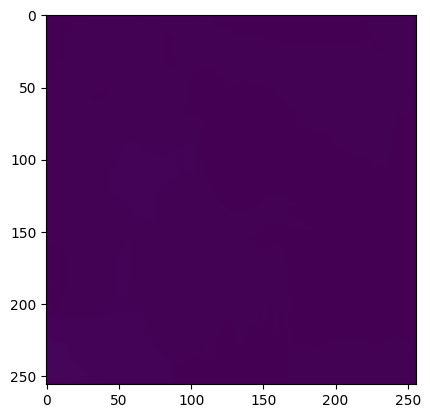

In [111]:
import matplotlib.pyplot as plt
import numpy as np

print(np.where(batch_cub.concepts[1].cpu()))

plt.imshow(predictions_cub[0].segmentation_module.mask_logits[0].detach().cpu()[17].sigmoid(), vmin=0, vmax=1)

In [176]:
import matplotlib.pyplot as plt
import torch

def plot_predictions_grid_masks_paper_seamless(
    df, predictions, batch, concept_names,
    img_idx=0, concept_idx=0, dataset="CUB_112",
    figsize=None, alpha=0.4, cmap="magma",
    save:bool=False
):
    # 1. Bild De-normalisieren
    images = batch.images
    mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1, 3, 1, 1)
    images_denorm = (images * std + mean).clamp(0, 1)
    img_np = images_denorm[img_idx].permute(1, 2, 0).cpu().numpy()

    # 2. Daten filtern
    df_filtered = df[df["Dataset"] == dataset].copy()
    filtered_preds = [p for p, (_, row) in zip(predictions, df.iterrows()) if row["Dataset"] == dataset]
    
    unique_modules = df_filtered["Concept Module"].unique().tolist()
    module_to_col = {name: i + 1 for i, name in enumerate(unique_modules)} # +1 wegen Originalbild
    n_cols = len(unique_modules) + 1 # +1 für die "Input Image" Spalte

    if figsize is None:
        figsize = (n_cols * 2.5, 5.0)

    # wspace=0 und hspace=0 für nahtlose Übergänge
    fig, axes = plt.subplots(2, n_cols, figsize=figsize, squeeze=False, 
                             gridspec_kw={'wspace': 0.0, 'hspace': 0.0})
    
    concept_name = concept_names[concept_idx]

    # --- INPUT IMAGE (Spalte 0) ---
    for r in range(2):
        axes[r, 0].imshow(img_np)
        axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
        # Optionaler Label für das Original
        if r == 0: axes[r, 0].set_title("Input Image", fontsize=9, fontweight="bold", pad=2)

    # --- KONZEPT MASKEN ---
    for i, row in df_filtered.iterrows():
        col_idx = module_to_col[row["Concept Module"]]
        row_idx = 1 if row["uses_mask_reg"] else 0
        ax = axes[row_idx, col_idx]
        
        # Maske berechnen
        mask = filtered_preds[i].segmentation_module.mask_logits[img_idx].detach().cpu()[concept_idx].sigmoid().numpy()
        
        ax.imshow(img_np)
        ax.imshow(mask, cmap=cmap, alpha=alpha, vmin=0, vmax=1)
        
        # Titel nur in der oberen Zeile anzeigen (um Platz zu sparen)
        if row_idx == 0:
            ax.set_title(row["Concept Module"], fontsize=9, fontweight="bold", pad=2)
            
        ax.set_xticks([]); ax.set_yticks([])

    # Rahmen und Labels anpassen
    for r in range(2):
        axes[r, 0].set_ylabel("With\nL1-Reg." if r == 1 else "Without\nL1-Reg.", 
                               fontsize=10, fontweight="bold", labelpad=10)
        for c in range(n_cols):
            # Dünne weiße Linien als Trennung (statt dicker Rahmen)
            for spine in axes[r, c].spines.values():
                spine.set_edgecolor("white")
                spine.set_linewidth(0.5)

    fig.suptitle(f"Concept Visualization: {concept_name}", fontsize=12, fontweight="bold", y=1.05)
    
    # Subplots_adjust für präzise Kontrolle der Ränder
    plt.subplots_adjust(left=0.1, right=0.98, top=0.88, bottom=0.05)

    if save:
        plt.savefig(f"thesis-figures/extended_cbm/outputs/mask_reg_{img_idx}_{concept_name}.pdf".replace('::', '_'))
    
    return fig

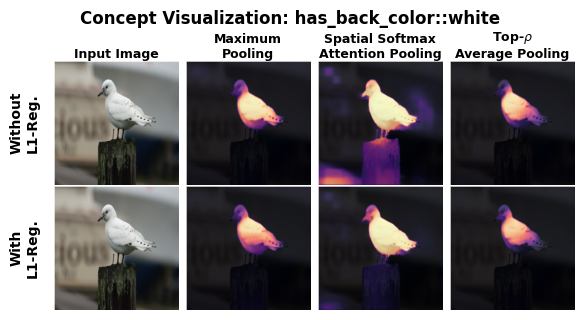

In [177]:
_ = plot_predictions_grid_masks_paper_seamless(
    combined,         # dein DataFrame
    predictions_cub,  # Liste der Prediction-Objekte in gleicher Reihenfolge
    img_idx=0,        # erste Bild im Batch
    concept_idx=29,   # gewünschtes Konzept
    dataset='CUB_112',
    figsize=(6, 3),
    batch=batch_cub,
    concept_names=train_dataset_cub.concepts.to_list(),
    alpha=0.8,
    save=True
)

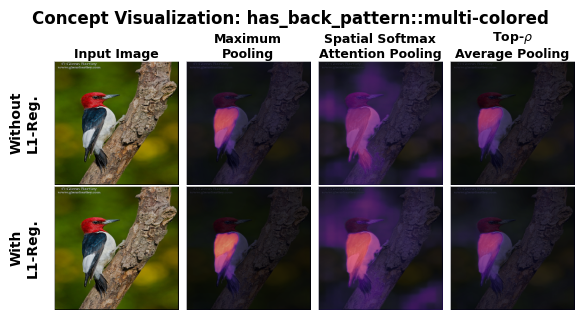

In [178]:
_ = plot_predictions_grid_masks_paper_seamless(
    combined,         # dein DataFrame
    predictions_cub,  # Liste der Prediction-Objekte in gleicher Reihenfolge
    img_idx=1,        # erste Bild im Batch
    concept_idx=85,   # gewünschtes Konzept
    dataset='CUB_112',
    figsize=(6, 3),
    batch=batch_cub,
    concept_names=train_dataset_cub.concepts.to_list(),
    alpha=0.8,
    save=True
)

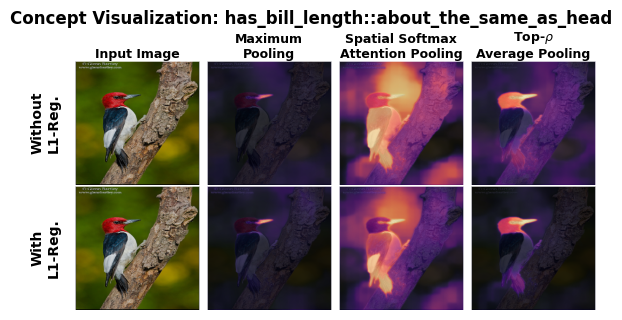

In [179]:
_ = plot_predictions_grid_masks_paper_seamless(
    combined,         # dein DataFrame
    predictions_cub,  # Liste der Prediction-Objekte in gleicher Reihenfolge
    img_idx=1,        # erste Bild im Batch
    concept_idx=51,   # gewünschtes Konzept
    dataset='CUB_112',
    figsize=(6, 3),
    batch=batch_cub,
    concept_names=train_dataset_cub.concepts.to_list(),
    alpha=0.8,
    save=True
)

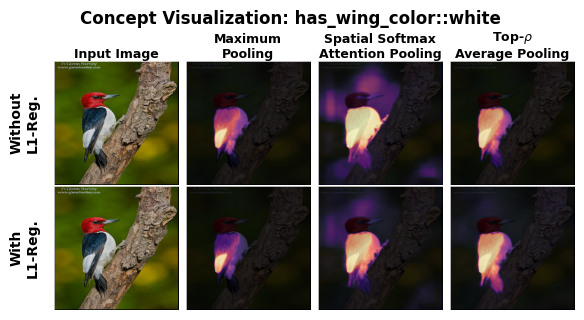

In [180]:
_ = plot_predictions_grid_masks_paper_seamless(
    combined,         # dein DataFrame
    predictions_cub,  # Liste der Prediction-Objekte in gleicher Reihenfolge
    img_idx=1,        # erste Bild im Batch
    concept_idx=8,   # gewünschtes Konzept
    dataset='CUB_112',
    figsize=(6, 3),
    batch=batch_cub,
    concept_names=train_dataset_cub.concepts.to_list(),
    alpha=0.8,
    save=True
)

In [181]:
combined

,run_id,Concept Module,epoch,Dataset,uses_mask_reg
0,cmxceof3,Maximum\nPooling,23,CUB_112,True
1,g3c6b6bf,Spatial Softmax\nAttention Pooling,23,CUB_112,True
2,xkfv5cvz,Top-$\rho$\nAverage Pooling,19,CUB_112,True
3,frtwr5la,Spatial Softmax\nAttention Pooling,23,CUB_112,False
4,gv70wmzz,Top-$\rho$\nAverage Pooling,19,CUB_112,False
5,nazemmyd,Maximum\nPooling,23,CUB_112,False


In [182]:
predictions_cub[0].segmentation_module.mask_logits.detach().cpu()[1,31].sigmoid().mean()

tensor(0.0443)

In [183]:
batch_cub.image_ids

[np.int64(3640), np.int64(11218), np.int64(478), np.int64(10281)]